In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

In [22]:

data3 = np.loadtxt("./Data-20262006/01.dat")


In [23]:
datasets = [
    # (data1, "300 K", 'red', 'o'),
    # (data2, "290 K", 'blue', 's'),
    (data3, "280 K", 'green', '^'),
    # (data4, "270 K", 'orange', 'D'),
    # (data5, "260 K", 'purple', 'p'),
    # (data6, "250 K", 'brown', '*'),
    # (data7, "240 K", 'pink', '8'),
    # (data8, "230 K", 'black', 'P'),
    # (data9, "220 K", 'gray', 'H'),


    # (data9, "300 K", 'olive', 'X'),
    # (data10, "290 K", 'cyan', 'v'),
    # (data11, "280 K", 'magenta', '<'),
    # (data12, "270 K", 'lime', '>'),
    # (data13, "260 K", 'teal', 'o'),
    # (data14, "250 K", 'navy', 's'),
    # (data15, "240 K", 'maroon', '^'),
    # (data16, "230 K", 'silver', 'D'),
    # (data17, "220 K", 'gold', 'p')
]

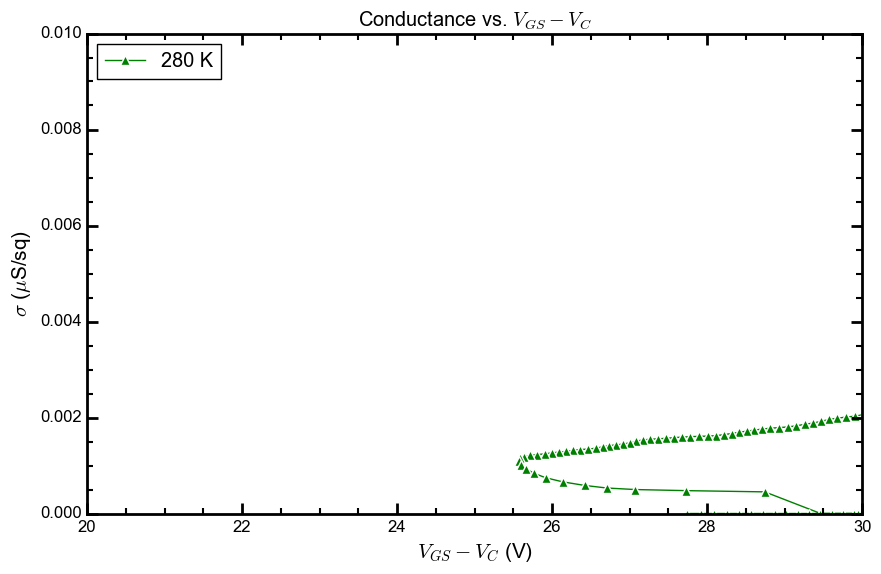

In [24]:
for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5* (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]

    window_size = 1
    window = np.ones(window_size) / window_size

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6
    legend_label = label if label in {"300 K", "290 K", "280 K"} else "_nolegend_"
    plt.plot(V_del_smooth, sigma_plot, label=legend_label, color=color, marker=marker, linestyle='-', markeredgecolor="white", markeredgewidth=1, markersize=7)

plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq)")  
plt.xlim(20, 30)
plt.ylim(0, 0.01)
plt.title("Conductance vs. $V_{GS} - V_C$")
plt.legend(numpoints=1, loc='upper left')
plt.show()


280 K: slope = 0.00148325, intercept = -0.0397164, R² = 0.0313, V_T = 26.78 V, mu = 2.64e-01 cm²/Vs


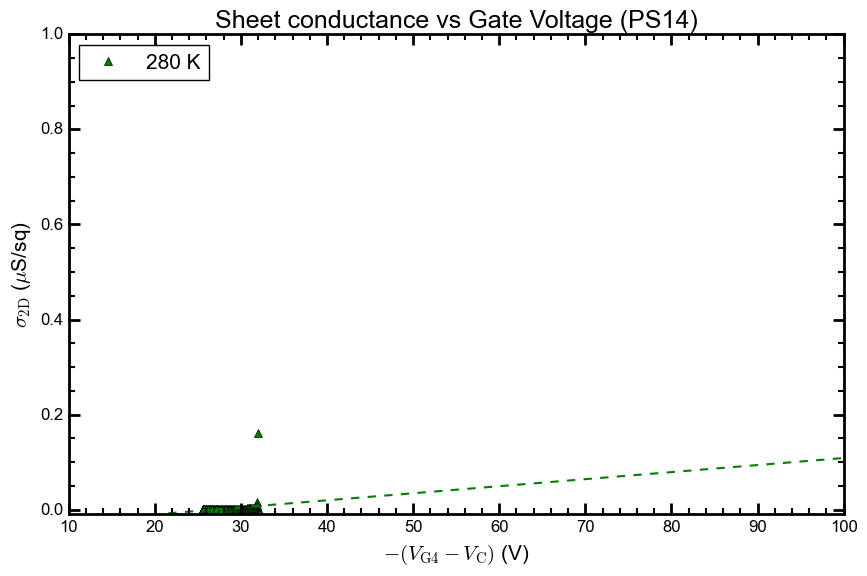

[0.26368842]
[26.77666448]


In [25]:

C = 1.8e-9
A = 32e-6
Ci = C / A

mu_vals = np.array([])
V_T_vals = np.array([])

fit_ranges = {
    "300 K": (25, 30),
    "290 K": (25, 40),
    "280 K": (25, 45),
    "270 K": (40, 63),
    "260 K": (46, 53),
    "250 K": (30, 45),
    "240 K": (40, 63),
    "230 K": (49, 54),
    "220 K": (50, 57),
}

for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    V_del = -(V_GS - V_C)

    legend_label = label if label in {"300 K", "290 K", "280 K"} else "_nolegend_"
    plt.plot(
        V_del,
        sigma * 1e6,
        label=legend_label,
        color=color,
        marker=marker,
        markevery=1,
        ls='None',
        markersize=6,
    )

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del >= fit_vmin) & (V_del <= fit_vmax)
    x_fit = V_del[mask]
    y_fit = sigma[mask] * 1e6

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        V_T = -intercept / slope
        mu = slope / Ci * 1e-2
        mu_vals = np.append(mu_vals, mu)
        V_T_vals = np.append(V_T_vals, V_T)
        print(f"{label}: slope = {slope:.6g}, intercept = {intercept:.6g}, R² = {np.corrcoef(x_fit, y_fit)[0, 1]**2:.4f}, V_T = {V_T:.2f} V, mu = {mu:.2e} cm²/Vs")
        x_line = np.linspace(10, 100, 200)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            color=color,
            lw=1.5,
            linestyle='--',
        )

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)", fontsize=15)
plt.xlim(10, 100)
plt.ylim(-0.01, 1.0)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title("Sheet conductance vs Gate Voltage (PS14)", fontsize=18)
# plt.savefig("vdP_sigma.eps", format='eps')
plt.show()

print(mu_vals)
print(V_T_vals)


In [26]:
for idx, (data, label, color, marker) in enumerate(datasets):
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    V_del = -(V_GS - V_C)


    mu_var = sigma*1e4 / (Ci * (V_del - V_T_vals[np.where(label == np.array(list(fit_ranges.keys())))[0]])) 
    if label in {"300 K", "290 K", "280 K"}:
        legend_label = f"{label}, $\\mu$ = {mu_vals[idx]:.2f} cm$^2$/Vs"
    else:
        legend_label = "_nolegend_"
    plt.plot(
        V_del,
        mu_var,
        label=legend_label,
        color=color,
        marker=marker,
        markevery=1,
        markersize=8,
        lw=2,markeredgecolor="white", markeredgewidth=1
    )
    plt.axhline(mu_vals[np.where(label == np.array(list(fit_ranges.keys())))[0]], color=color, ls='--', lw=1.5)
plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"Mobility (cm²/Vs)", fontsize=15)
plt.xlim(20, 40)
plt.ylim(2, 6)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=15)
plt.title("Mobility vs Gate Voltage (Cryostat)", fontsize=18)
plt.savefig("vdP_mobility.eps", format='eps')
plt.show()

    


IndexError: index 2 is out of bounds for axis 0 with size 1

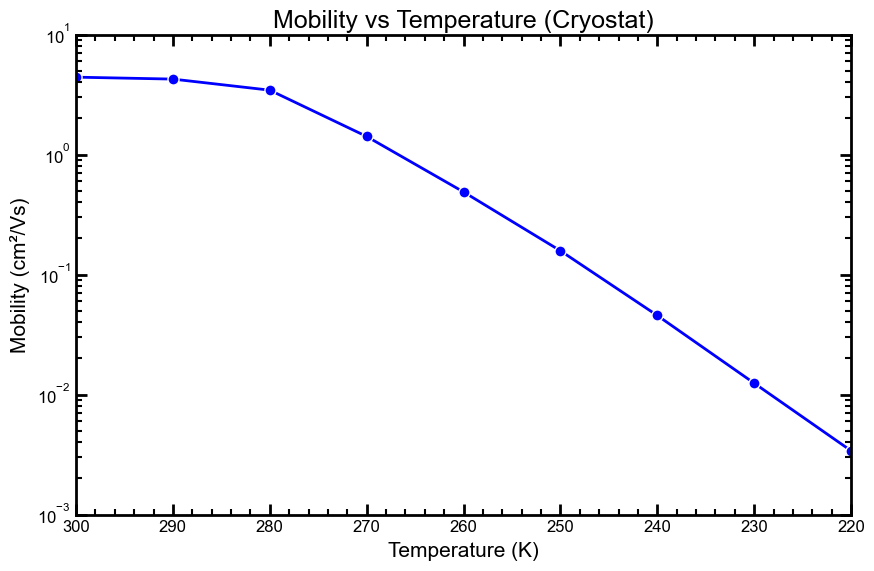

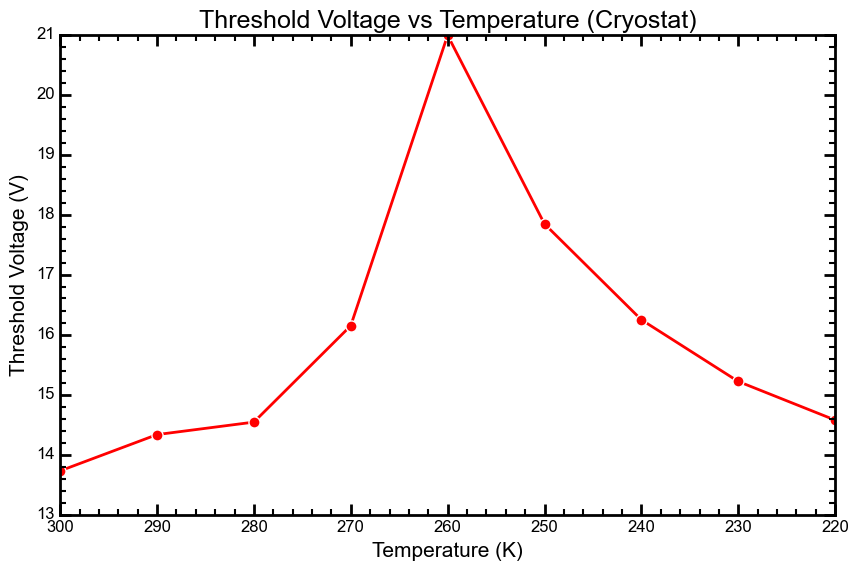

In [ ]:
T_vals = np.array([300, 290, 280, 270, 260, 250, 240, 230, 220])
plt.semilogy(T_vals, mu_vals, marker='o', color='blue', lw=2,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel("Temperature (K)", fontsize=15)
plt.ylabel("Mobility (cm²/Vs)", fontsize=15)
plt.title("Mobility vs Temperature (Cryostat)", fontsize=18)
plt.xlim(300,220)
plt.show()

plt.plot(T_vals, V_T_vals, marker='o', color='red', lw=2,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel("Temperature (K)", fontsize=15)
plt.ylabel("Threshold Voltage (V)", fontsize=15)
plt.title("Threshold Voltage vs Temperature (Cryostat)", fontsize=18)
plt.xlim(300, 220)
plt.show()
